In [1]:
# Random Data creation and saving it in .csv file
import pandas as pd
import numpy as np

np.random.seed(42)

# Number of students (rows)
n = 200

# Generate synthetic data
study_hours = np.random.randint(1, 11, n)          # 1 to 10 hours
attendance = np.random.randint(40, 101, n)         # 40% to 100%
previous_score = np.random.randint(30, 96, n)      # 30 to 95 marks
assignment_marks = np.random.randint(30, 101, n)   # 30 to 100 marks

final_score = (0.3*previous_score + 0.3*assignment_marks + 0.4*attendance/100*100)
result = ["Pass" if score >= 50 else "Fail" for score in final_score]

# Creating DataFrame
df = pd.DataFrame({
    "StudyHours": study_hours,
    "Attendance": attendance,
    "PreviousScore": previous_score,
    "AssignmentMarks": assignment_marks,
    "Result": result
})

print("📂 Sample of Student Performance Dataset:\n")
print(df.head())


📂 Sample of Student Performance Dataset:

   StudyHours  Attendance  PreviousScore  AssignmentMarks Result
0           7          61             55               91   Pass
1           4          50             79               92   Pass
2           8          87             54               54   Pass
3           5          55             53               85   Pass
4           7          72             42               62   Pass


In [3]:
# Saveing the dataset to CSV file
df.to_csv("student_performance.csv", index=False)

print("\n✅ CSV file 'student_performance.csv' created successfully!")
# So now the CSV file is created and saved into the Home of jupyter notebook and it contains 200 rows of student data.


✅ CSV file 'student_performance.csv' created successfully!


Importing the Required Libraries.

In [6]:
import pandas as pd        # For handling datasets
import numpy as np         # For numerical operations
import matplotlib.pyplot as plt  # For visualization
import seaborn as sns      # For prettier plots
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.linear_model import LinearRegression, LogisticRegression  # ML models
from sklearn.metrics import accuracy_score, mean_squared_error  # For evaluation


In [8]:
df = pd.read_csv("student_performance.csv")
df.head()

,StudyHours,Attendance,PreviousScore,AssignmentMarks,Result
0,7,61,55,91,Pass
1,4,50,79,92,Pass
2,8,87,54,54,Pass
3,5,55,53,85,Pass
4,7,72,42,62,Pass


In [10]:
# Preprocessing the data
df['Result'] = df['Result'].map({'Pass': 1, 'Fail': 0})  # Convert Pass/Fail to 1/0


In [12]:
df

,StudyHours,Attendance,PreviousScore,AssignmentMarks,Result
0,7,61,55,91,1
1,4,50,79,92,1
2,8,87,54,54,1
3,5,55,53,85,1
4,7,72,42,62,1
...,...,...,...,...,...
195,8,87,49,54,1
196,5,78,90,46,1
197,4,68,68,42,1
198,2,81,30,54,1


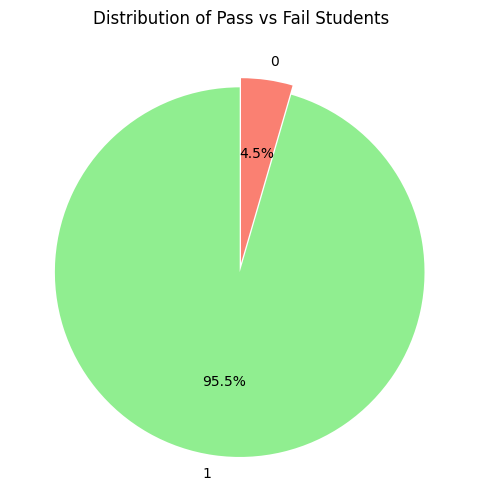

In [26]:
# Count Pass vs Fail
result_counts = df['Result'].value_counts()

# Create Pie Chart
plt.figure(figsize=(6,6))
plt.pie(result_counts, 
        labels=result_counts.index, 
        autopct='%1.1f%%', 
        colors=['lightgreen','salmon'], 
        startangle=90, 
        explode=(0.05,0))  # Slightly separate the first slice

plt.title("Distribution of Pass vs Fail Students")
plt.show()


I am using the Two basic ML models for predicting the data:
    Logistic Regression → Predict Pass/Fail

    Linear Regression → Predict Final Score (continuous)

In [32]:
# Logistic Regression
X = df[['StudyHours', 'Attendance', 'PreviousScore', 'AssignmentMarks']]
y = df['Result']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Training the model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# Accuracy
print("\n🎯 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Predicted Results:", y_pred)
print("Actual Results:", list(y_test))



🎯 Logistic Regression Accuracy: 1.0
Actual Results: [1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [38]:
# Linear Regression
X = df[['StudyHours', 'Attendance', 'AssignmentMarks']]
y = df['PreviousScore']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predict
y_pred = lin_model.predict(X_test)

# Evaluation
print("\n📊 Linear Regression Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Predicted Scores:", y_pred)
print("Actual Scores:", list(y_test))



📊 Linear Regression Mean Squared Error: 362.91517810202936
Predicted Scores: [67.58310082 60.79346095 75.14948911 58.61580062 69.17175347 60.752005
 51.33613087 64.23288691 51.50021811 62.0981222  58.88050372 60.69864996
 57.98420173 56.5329588  63.48668592 60.68015383 68.80227524 63.65672271
 67.66105375 57.61486819 68.70552929 70.17011098 72.76515033 53.35371855
 71.01835998 60.38331895 59.49747638 57.84807947 68.02522992 65.18269615
 64.06141045 64.48216409 53.54562609 59.33661155 53.29168683 70.83498443
 59.59645418 73.09138986 63.13104173 67.32965684 67.3508801  68.44276115
 57.33990406 59.7296971  62.60372269 59.4969811  54.89223857 70.4102162
 63.47190749 73.8163676  50.0602343  52.97283651 66.50842845 53.63964491
 63.40922828 63.0175824  48.68758427 53.73767832 68.87363113 57.33925657]
Actual Scores: [62, 44, 44, 68, 66, 87, 86, 71, 95, 48, 55, 74, 46, 39, 48, 66, 87, 45, 48, 80, 65, 95, 54, 64, 51, 30, 30, 45, 53, 52, 74, 92, 30, 68, 82, 73, 91, 88, 87, 62, 63, 68, 76, 51, 93

Logistic Regression tells us whether a student will Pass/Fail.

Linear Regression estimates the score.

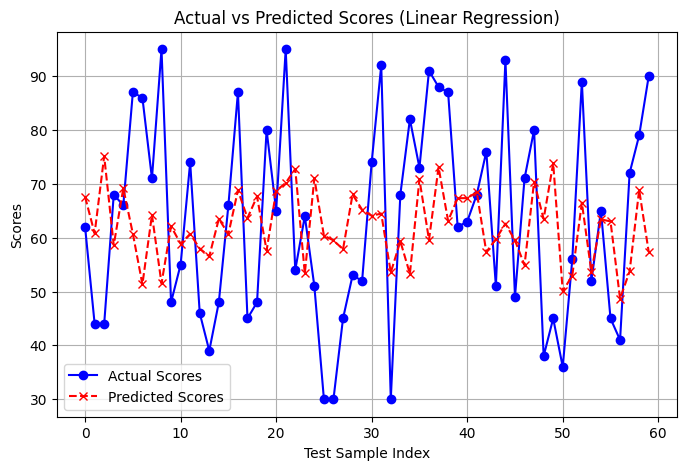

In [41]:
# Plot Actual vs Predicted Scores
plt.figure(figsize=(8,5))

# Plot actual scores
plt.plot(range(len(y_test)), list(y_test), marker='o', label='Actual Scores', color='blue')

# Plot predicted scores
plt.plot(range(len(y_pred)), y_pred, marker='x', linestyle='--', label='Predicted Scores', color='red')

plt.title("Actual vs Predicted Scores (Linear Regression)")
plt.xlabel("Test Sample Index")
plt.ylabel("Scores")
plt.legend()
plt.grid(True)
plt.show()


Using the Decision Tree and Random Forest for prediction of data

In [58]:
# Decision Tree (classification)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Random Forest (classification)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Evaluation helper
def classification_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# Compute metrics
results = {
    'Logistic Regression': classification_metrics(y_test, log_pred),
    'Linear Regression (thresholded)': classification_metrics(y_test, lin_pred),
    'Decision Tree': classification_metrics(y_test, dt_pred),
    'Random Forest': classification_metrics(y_test, rf_pred)
}

# Build comparison table
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Model'})
metrics_df[['Accuracy','Precision','Recall','F1-Score']] = metrics_df[['Accuracy','Precision','Recall','F1-Score']].astype(float).round(3)

# Select best model by F1-Score
best_row = metrics_df.loc[metrics_df['F1-Score'].idxmax()]
best_model_name = best_row['Model']
best_model_f1 = best_row['F1-Score']

# Output results
from IPython.display import display
display(metrics_df)
print(f"Best model by F1-Score: {best_model_name} (F1-Score = {best_model_f1})")

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000,1.000,1.000,1.000
1,Linear Regression (thresholded),0.950,0.950,1.000,0.974
2,Decision Tree,0.950,0.982,0.965,0.973
3,Random Forest,0.933,0.949,0.982,0.966


Best model by F1-Score: Logistic Regression (F1-Score = 1.0)


In [60]:
# Confusion matrix for the best model
best_pred_map = {
    'Logistic Regression': log_pred,
    'Linear Regression (thresholded)': lin_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred
}
best_pred = best_pred_map[best_model_name]
cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(cm, index=['Actual_Fail','Actual_Pass'], columns=['Pred_Fail','Pred_Pass'])
display(cm_df)

,Pred_Fail,Pred_Pass
Actual_Fail,3,0
Actual_Pass,0,57
